In [26]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Normalize manually (still from scratch)
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=22101234,
    shuffle=True
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=22101234,
    shuffle=True
)

print(len(X_train), len(X_val), len(X_test))


105 22 23


In [27]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Euclidean Distance Function

In [28]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

### `Predict ONE test sample using KNN`

In [29]:
def knn_predict_single(x_test, X_train, y_train, k):
    distances = []

    # (a) Compute distance from test point to all training points
    for i in range(len(X_train)):
        dist = euclidean_distance(x_test, X_train[i])
        distances.append((dist, y_train[i]))

    # (b) Sort distances in ascending order
    distances.sort(key=lambda x: x[0])

    # (c) Select K nearest neighbors
    k_neighbors = distances[:k]

    # (d) Majority voting
    labels = [label for _, label in k_neighbors]
    predicted_class = Counter(labels).most_common(1)[0][0]

    return predicted_class

# Predict ALL test samples


In [30]:
def knn_predict(X_test, X_train, y_train, k):
    predictions = []

    for x in X_test:
        pred = knn_predict_single(x, X_train, y_train, k)
        predictions.append(pred)

    return np.array(predictions)

Accuracy Calculation


In [31]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

Evaluate for different K values

In [32]:

k_values = [1, 3, 5, 7]
accuracies = []

for k in k_values:
    # y_pred = knn_predict(X_val, X_train, y_train, k)  #with validation
    # acc = accuracy(y_val, y_pred)

    y_pred = knn_predict(X_test, X_train, y_train, k) #only train test
    acc = accuracy(y_test, y_pred)
    accuracies.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

    best_k = k_values[np.argmax(accuracies)]
    print("Best K based on validation:", best_k)


K = 1, Accuracy = 1.0000
Best K based on validation: 1
K = 3, Accuracy = 1.0000
Best K based on validation: 1
K = 5, Accuracy = 1.0000
Best K based on validation: 1
K = 7, Accuracy = 1.0000
Best K based on validation: 1


Plot K vs Accuracy

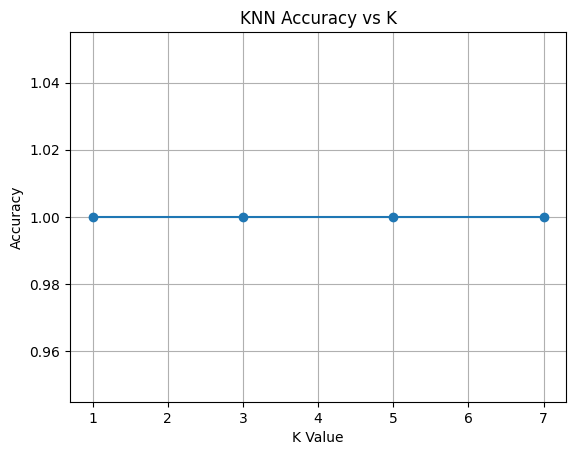

In [33]:

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)
plt.show()
